In [1]:
# Figure font sizing for journal submission.
# Raise FONT_SCALE (e.g. to 1.4) and re-run to enlarge ALL text uniformly
# across every figure in this notebook. FONT_SCALE = 1.0 reproduces the
# original figures exactly (10.0 is the matplotlib default font.size, and the
# title/tick/legend sizes are relative to it, so they scale automatically).
import matplotlib as mpl

FONT_SCALE = 1.4
mpl.rcParams["font.size"] = 10.0 * FONT_SCALE


### Imports

In [2]:
import pathlib
import re

import axelrod as axl
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import dask.dataframe as dd
import sklearn
from sklearn.feature_selection import RFE, SequentialFeatureSelector, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import json

from matplotlib.transforms import Bbox

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


import matplotlib.cm as cm

from matplotlib.patches import FancyBboxPatch

### Functions for Plotting

In [116]:
cmap = matplotlib.colormaps.get_cmap('coolwarm')

def _px_to_data_x(ax, px: float) -> float:
    """Convert a horizontal pixel width to data units for a given Axes."""
    inv = ax.transData.inverted()
    x0, _ = inv.transform((0, 0))
    x1, _ = inv.transform((px, 0))
    return x1 - x0

def draw_minbox_label(ax, x, y, text, *, min_w_px=70, pad_px=6, box_h_data=0.7, fontsize=8 * FONT_SCALE):
    """Draw a minimal rounded box behind centered text with a min pixel width."""
    fig = ax.figure
    tmp = ax.text(0, 0, text, fontsize=fontsize, visible=False)
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    text_w_px = tmp.get_window_extent(renderer=renderer).width
    tmp.remove()

    width_data = _px_to_data_x(ax, max(min_w_px, text_w_px + 2 * pad_px))

    rect = FancyBboxPatch(
        (x - width_data / 2, y - box_h_data / 2),
        width_data, box_h_data,
        boxstyle="round,pad=0.0,rounding_size=0.04",
        fc="white", ec="black", lw=1.0, zorder=1
    )
    ax.add_patch(rect)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, zorder=2)

def _add_bottom_colorbar_coop(fig, ax, im, label, *, size="5%", pad=0.4, fontsize=10 * FONT_SCALE):
    """Attach a horizontal colorbar under a given Axes."""
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size=size, pad=pad)
    cb = fig.colorbar(im, cax=cax, orientation="horizontal")
    cb.ax.tick_params(labelsize=8 * FONT_SCALE)
    cb.set_ticks([i for i in np.arange(0, 1.2, 0.2)])
    cb.set_label(label, fontsize=fontsize)
    return cb


def _add_bottom_colorbar_symmetry(fig, ax, im, label, *, size="5%", pad=0.4, fontsize=10 * FONT_SCALE):
    """Attach a horizontal colorbar under a given Axes."""
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size=size, pad=pad)
    cb = fig.colorbar(im, cax=cax, orientation="horizontal")
    cb.ax.tick_params(labelsize=8 * FONT_SCALE)
    cb.set_label(label, fontsize=fontsize)
    cb.set_ticks([-1, -0.5, 0, 0.5, 1])
    return cb

# --------------------------- Panels ---------------------------

def panel_A_scatter_trend(ax, df, label, xcol="Rank", ycol="Mean Cooperation Rate", degree=16):
    """Scatter of rank vs cooperation + polynomial trend."""
    ax.scatter(df[xcol], df[ycol], s=10)
    z = np.polyfit(df[xcol], df[ycol], degree)
    p = np.poly1d(z)
    xs = np.linspace(df[xcol].min(), df[xcol].max(), 1000)
    ax.plot(xs, p(xs), "r--", label=f"Trend ($x^{{{degree}}}$)")
    ax.set_ylabel("Cooperation rate", fontsize=10 * FONT_SCALE)
    ax.set_xlabel(label)
    ax.set_ylim(0, 1.1)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.legend(fontsize=9 * FONT_SCALE)


def panel_C_cooperation(ax, fig, matrix, *, cmap="viridis"):
    """Cooperation matrix heatmap with bottom colorbar."""
    im = ax.matshow(matrix, cmap=cmap, vmin=0, vmax=1)
    _add_bottom_colorbar_coop(fig, ax, im, "Cooperation rate")
    return im

def panel_D_symmetry(ax, fig, matrix, *, cmap="coolwarm_r"):
    """Anti-symmetry (retaliation) heatmap with bottom colorbar."""
    heatmap = matrix.values if hasattr(matrix, "values") else np.asarray(matrix)
    symmetric = heatmap - heatmap.T
    im = ax.matshow(symmetric, cmap=cmap, vmin=-1, vmax=1)
    _add_bottom_colorbar_symmetry(fig, ax, im, "Difference in cooperation rate")
    return im

def panel_E_rank_flow(ax, old_rank: dict, new_rank: dict, relative_new_rank: dict, cmap, label):
    """Arrow flow from original rank to full tournament rank with labels."""
    strategies = sorted(set(old_rank) & set(new_rank))
    deltas = {s: relative_new_rank[s] - old_rank[s] for s in strategies}
    max_d = max(abs(d) for d in deltas.values()) or 1

    xL, xR = 0.0, 1.0
    yL = np.array([old_rank[s] for s in strategies], dtype=float)
    yR = np.array([relative_new_rank[s] for s in strategies], dtype=float)

    ax.set_xlim(-0.25, 1.25)
    ax.set_ylim(len(strategies) + 1, 0)

    # Arrows
    for i, s in enumerate(strategies):
        d = deltas[s]
        if d == 0:
            color, lw, ls = "0.7", 1.2, (0, (1, 2))
        else:
            color = cmap(1.0) if d < 0 else cmap(0.0)
            lw = 1.2 + 2.2 * abs(d) / max_d
            ls = "solid"

        ax.annotate(
            "",
            xy=(xR - 0.04, yR[i]),
            xytext=(xL + 0.04, yL[i]),
            arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                            linestyle=ls, alpha=0.95, shrinkA=0, shrinkB=0),
            zorder=0
        )

    # Labels
    for i, s in enumerate(strategies):
        draw_minbox_label(ax, xL - 0.03, yL[i], f"{s}:{old_rank[s]}", min_w_px=90, pad_px=6, box_h_data=0.8, fontsize=7 * FONT_SCALE)
        draw_minbox_label(ax, xR + 0.03, yR[i], f"{new_rank[s]}", min_w_px=40, pad_px=6, box_h_data=0.8, fontsize=7 * FONT_SCALE)

    # Cosmetics
    ax.set_yticks([])
    ax.set_xticks([xL - 0.03, xR + 0.03], labels=["Original rank", label])
    for side in ("top", "left", "right"):
        ax.spines[side].set_visible(False)

# --------------------------- Layout + Orchestration ---------------------------

def build_mosaic(figsize=(10, 12),
                 width_ratios=(2, 1),
                 height_ratios=(0.5, 0.5, 1, 1),
                 hspace=0.05, wspace=0.0,
                 constrained=True):
    """Create the subplot mosaic and return (fig, axes_dict)."""
    mosaic = """EA
                EB
                EC
                ED"""
    fig, axes = plt.subplot_mosaic(
        mosaic,
        figsize=figsize,
        gridspec_kw={
            "hspace": hspace,
            "wspace": wspace,
            "width_ratios": list(width_ratios),
            "height_ratios": list(height_ratios),
        },
        constrained_layout=constrained
    )
    return fig, axes

def panel_B_violin(ax, df, *, base_col="Mean Cooperation Rate",
                   compare_col="Reproduced Mean Cooperation Rate",
                   label='',
                   colors=("tab:green", "tab:blue")):
    """Two-group violin plot: base vs compare."""
    base_vals = df[base_col].dropna().values
    comp_vals = df[compare_col].dropna().values
    data = [base_vals, comp_vals]
    positions = [1, 2]

    parts = ax.violinplot(
        data,
        positions=positions,
        showmeans=True, showmedians=False,
        showextrema=False, widths=0.7
    )

    # Color the violin bodies
    for pc, fc in zip(parts["bodies"], colors):
        pc.set_facecolor(fc)
        pc.set_edgecolor("black")

    # Color the mean lines to match each violin
    parts["cmeans"].set_color(colors)   # accepts a sequence for multiple segments
    parts["cmeans"].set_linewidth(2)

    # Annotate mean values just above the mean lines
    means = [np.mean(base_vals), np.mean(comp_vals)]
    for x, m, c in zip(positions, means, colors):
        ax.text(x, m + 0.02, f"{m:.3f}", ha="center", va="bottom",
                fontsize=9 * FONT_SCALE, color=c, fontweight="bold", clip_on=False)

    # Labels / ticks
    ax.set_xticks([1, 2]
    )
    ax.set_xticklabels(
        [f"{label.replace(' rank', '').replace(" tournament", "\ntournament")}",
         f"Reproduced\ntournament"], fontsize=9 * FONT_SCALE
    )
    ax.set_ylabel("Cooperation rate", fontsize=10 * FONT_SCALE)
    ax.set_ylim(0, 1.1)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])



    
def plot_panels(ranking_df,
                cooperation_df,
                label,
                col_x_panel_B,
                old_rank: dict,
                new_rank: dict,
                relative_new_rank: dict,
                violin_colors=("tab:green", "tab:blue"),
                cmap_heat=plt.cm.viridis,
                cmap_flow=plt.cm.coolwarm_r,
                figsize=(10, 12),
                save_path=None):
    """
    Orchestrate the full figure. Returns (fig, axes).
    Pass different dataframes/dicts to reuse.
    """
    fig, axes = build_mosaic(figsize=figsize)

    # Panel E first (left column, tall)
    panel_E_rank_flow(axes["E"], old_rank, new_rank, relative_new_rank, cmap_flow, label)

    # Panel A (top-right)
    panel_A_scatter_trend(axes["A"], ranking_df, xcol=col_x_panel_B, label=label)

    # Panel B (violin, right column second row)
    panel_B_violin(axes["B"], ranking_df,
                   base_col="Mean Cooperation Rate",
                   label=label,
                   colors=violin_colors)

    # Panels C/D (heatmaps)
    matrix = cooperation_rates[ranking_df.index].reindex(ranking_df.index)
    panel_C_cooperation(axes["C"], fig, matrix, cmap=cmap_heat.name if hasattr(cmap_heat, "name") else cmap_heat)
    panel_D_symmetry(axes["D"], fig, matrix, cmap=cmap_flow.name if hasattr(cmap_flow, "name") else cmap_flow)
    
    # Consistent x-ticks for A/C/D (ranks)
    n = len(ranking_df.index)
    for letter in "ACD":
        axes[letter].set_xticks(np.linspace(0, n - 1, 5), minor=False)
        axes[letter].set_xticks(range(0, n, 2), minor=True)
        axes[letter].set_xticklabels(np.linspace(1, n, 5).astype(np.int32), minor=False)

    for letter in "CD":
        axes[letter].set_yticks(np.linspace(0, n - 1, 5), minor=False)
        axes[letter].set_yticks(range(0, n, 2), minor=True)
        axes[letter].set_yticklabels(np.linspace(1, n, 5).astype(np.int32), minor=False)
        axes[letter].set_ylabel(label, fontsize=10 * FONT_SCALE)
        axes[letter].set_title(label, fontsize=10 * FONT_SCALE)

    # Panel letters
    fig.text(.08, 1.03, "a", fontsize=16 * FONT_SCALE, fontweight='bold', va='top', ha='left')
    fig.text(.655, 1.03, "b",
                   fontsize=16 * FONT_SCALE, fontweight='bold', va='top', ha='left')
    fig.text(.655, .83, "c",
                   fontsize=16 * FONT_SCALE, fontweight='bold', va='top', ha='left')
    fig.text(.655, .6, "d",
                   fontsize=16 * FONT_SCALE, fontweight='bold', va='top', ha='left')
    fig.text(.655, .27, "e",
                   fontsize=16 * FONT_SCALE, fontweight='bold', va='top', ha='left')

    bpos = axes["B"].get_position()
    axes["B"].set_position(Bbox.from_bounds(bpos.x0 + 0.005, bpos.y0 + 0.02, bpos.width, bpos.height - 0.02))

    if save_path:
        fig.savefig(save_path, transparent=True, bbox_inches="tight")

    return fig, axes

### Functions for Reading data

In [67]:
with open("./data/original_tournament/fortran_characteristics.json", "r") as f:
    characteristics = json.load(f)

def get_turns(filename):
    """
    Read the number of turns if included in the file name
    """
    match = re.search("[0-9]+(?=(_turns))", str(filename))
    return int(match.group(0))

def get_repetitions(filename):
    """
    Read the number of repetitions if included in the file name
    """
    match = re.search("[0-9]+(?=(_repetitions))", str(filename))
    return int(match.group(0))

def read_tournament_repetitions(files, player_names=None):
    """
    Read the scores from a collection of gz files 
    representing repetitions of tournaments.
    """
    number_of_opponents = len(player_names) - 1
    dfs = []
    keeping_turns_number = []
    for gz_path in files:
        dfs.append(pd.read_csv(str(gz_path), header=None).iloc[:,0:number_of_opponents + 1])
        
        turns = get_turns(gz_path)
        keeping_turns_number.append(turns)
        
        dfs[-1] /= turns * (number_of_opponents)  # Scale all metrics
        dfs[-1].columns = player_names
        
    df = pd.concat(dfs, ignore_index=True)
    return df

def read_payoff_matrix(files):
    arrays = []
    turns = []
    repetitions = 0
    for gz_path in files:
        repetitions += get_repetitions(gz_path)
        arrays.append(np.array(pd.read_csv(str(gz_path), header=None)))  # Read through pd to deal with float conversion
        turns.append(get_turns(str(gz_path)))
    payoff_matrix = sum(array * turn for turn, array in zip(turns, arrays)) / sum(turns)

    return payoff_matrix, repetitions


def get_results_of_sub_tournament(
    player_names, 
    payoff_matrix, 
    player_index, 
    characteristics=characteristics,
):
    player_indices = get_indices_of_players(player_names, player_index)
    player_index_mesh = np.ix_(player_indices, player_indices)
    payoff_sub_matrix = payoff_matrix[player_index_mesh]
    mean_payoffs = np.mean(payoff_sub_matrix, axis=1)
    median_payoffs = np.median(payoff_sub_matrix, axis=1)
    df = pd.DataFrame(
        {
            "Name": player_names,
            "Mean payoff": mean_payoffs,
            "Median payoff": median_payoffs,
        }
    )
    df["Rank"] = df["Mean payoff"].rank(ascending=False)
    original_ranks = []
    for name in df["Name"]:
        try:
            original_rank = characteristics[name]['original_rank']
        except KeyError:
            original_rank = None
        original_ranks.append(original_rank)
    df["Original Rank"] = original_ranks
    return df.sort_values("Rank")


def get_indices_of_players(player_names, player_index):
    """
    Returns the indices of the players in `player_names` from `player_index`
    """
    indices = []
    for player in player_names:
        indices.append(list(player_index).index(player))
    return indices

def add_superscript_to_name(string):
    if ("Evolved" in string) or ("PSO" in string):
        return string + r"\textsuperscript{\textdagger}"
    return string

### Original and Reproduced Results

In [6]:
second_tournament_strategies = [
    name for name in characteristics.keys()
    if characteristics[name]["original_rank"] is not None
]

In [7]:
original_tournament_data_path = pathlib.Path("./data/original_tournament/")
original_tournament_scores = read_tournament_repetitions(
                                   files=original_tournament_data_path.glob("*scores.gz"), 
                                   player_names=second_tournament_strategies)

In [8]:
original_tournament_payoff_matrix, original_repetitions = read_payoff_matrix(original_tournament_data_path.glob("*payoff_matrix.gz"))

In [9]:
reproduced = pd.DataFrame(original_tournament_payoff_matrix, 
                          second_tournament_strategies)
reproduced.columns = reproduced.index

In [10]:
reproduced["Scores"] = np.mean(original_tournament_payoff_matrix, axis=1)
reproduced["Reproduced Rank"] = reproduced["Scores"].rank(ascending=False).astype(int)
reproduced["Original Rank"] =  [characteristics[name]["original_rank"] for name in reproduced.index]
reproduced["Author"] =  [characteristics[name]["author"] for name in reproduced.index]
reproduced.sort_values("Original Rank", inplace=True)

In [11]:
original_rank = dict(zip(reproduced.index, reproduced['Original Rank']))
reproduced_rank = dict(zip(reproduced.index, reproduced['Reproduced Rank']))

In [12]:
original_tournament_cooperation_rates = read_payoff_matrix(original_tournament_data_path.glob("*cooperation_rates.gz"))[0].transpose()

cooperation_rates = pd.DataFrame(original_tournament_cooperation_rates, 
                                 second_tournament_strategies, 
                                 columns=second_tournament_strategies)
original_cooperation_rates = cooperation_rates.merge(reproduced[["Reproduced Rank"]], left_index=True, right_index=True)
original_cooperation_rates["Mean Cooperation Rate"] = np.mean(original_tournament_cooperation_rates, axis=1)
original_cooperation_rates.sort_values("Reproduced Rank", inplace=True)

In [13]:
reproduced_df = reproduced[["Author", "Scores", "Reproduced Rank", "Original Rank"]].round(4)
reproduced_df = reproduced_df.join(original_cooperation_rates[["Mean Cooperation Rate"]])
reproduced_df.head()

,Author,Scores,Reproduced Rank,Original Rank,Mean Cooperation Rate
k92r,Anatol Rapoport,2.8785,1,1,0.921831
k61r,Danny C Champion,2.7907,12,2,0.954240
k42r,Otto Borufsen,2.8607,2,3,0.916128
k49r,Rob Cave,2.8260,4,4,0.892220
k44r,William Adams,2.8260,3,5,0.881894


### Full tournament

In [14]:
full_tournament_data_path = pathlib.Path("./data/full_tournament/")
full_tournament_index = pd.read_csv(
    "./data/full_tournament/players.index",
    names=("Name",),
)
full_tournament_scores = read_tournament_repetitions(
                                   files=full_tournament_data_path.glob("*scores.gz"), 
                                   player_names=full_tournament_index["Name"],
)

In [15]:
full_tournament_payoff_matrix, full_repetitions = read_payoff_matrix(full_tournament_data_path.glob("*payoff_matrix.gz"))
library_summary_df = pd.read_csv("./data/library_tournament/std_summary.csv")[["Rank", "Name", "Cooperation_rating"]]
library_summary_df = library_summary_df.set_index("Name")
library_summary_df["Rank"] += 1
library_summary_df = library_summary_df.rename(columns={"Rank": "Library Rank", "Cooperation_rating": "Library Mean Cooperation Rate"})

In [16]:
full_tournament_cooperation_rate_matrix = read_payoff_matrix(full_tournament_data_path.glob("*cooperation_rates.gz"))[0].transpose()
full_scores = pd.DataFrame(full_tournament_payoff_matrix, 
                           full_tournament_index["Name"],
                           columns=full_tournament_index["Name"])
full_scores["Mean Score"] = np.mean(full_tournament_payoff_matrix, axis=1)
full_scores["Rank"] = full_scores["Mean Score"].rank(ascending=False).astype(int)

cooperation_rates = pd.DataFrame(full_tournament_cooperation_rate_matrix, 
                                 full_tournament_index["Name"], 
                                 columns=full_tournament_index["Name"])
cooperation_rates["Mean Cooperation Rate"] =  np.mean(full_tournament_cooperation_rate_matrix, axis=1)


full_scores = full_scores.join(cooperation_rates[["Mean Cooperation Rate"]]).sort_values("Rank")

full_ranking_df = full_scores[["Mean Score", "Rank", "Mean Cooperation Rate"]].round(4)
full_ranking_df = pd.merge(full_ranking_df, reproduced_df[["Original Rank", "Mean Cooperation Rate"]], left_index=True, right_index=True, how="outer").sort_values("Rank")
full_ranking_df = full_ranking_df.rename(columns={"Mean Cooperation Rate_x": "Mean Cooperation Rate", "Mean Cooperation Rate_y": "Reproduced Mean Cooperation Rate"})


full_ranking_df = full_ranking_df.join(library_summary_df)

full_ranking_df["Original Rank"] = full_ranking_df["Original Rank"].astype(pd.Int64Dtype())
full_ranking_df["Library Rank"] = full_ranking_df["Library Rank"].astype(pd.Int64Dtype())
full_ranking_df["Rank"] = full_ranking_df["Rank"].astype(pd.Int64Dtype())

In [17]:
full_tournament_rank = dict(zip(reproduced_df.index, [full_ranking_df['Rank'][i] for i in reproduced_df.index]))
order = sorted(reproduced_df.index, key=lambda s: (full_tournament_rank[s], original_rank[s]))

relative_full_tournament_rank = {s: i + 1 for i, s in enumerate(order)}

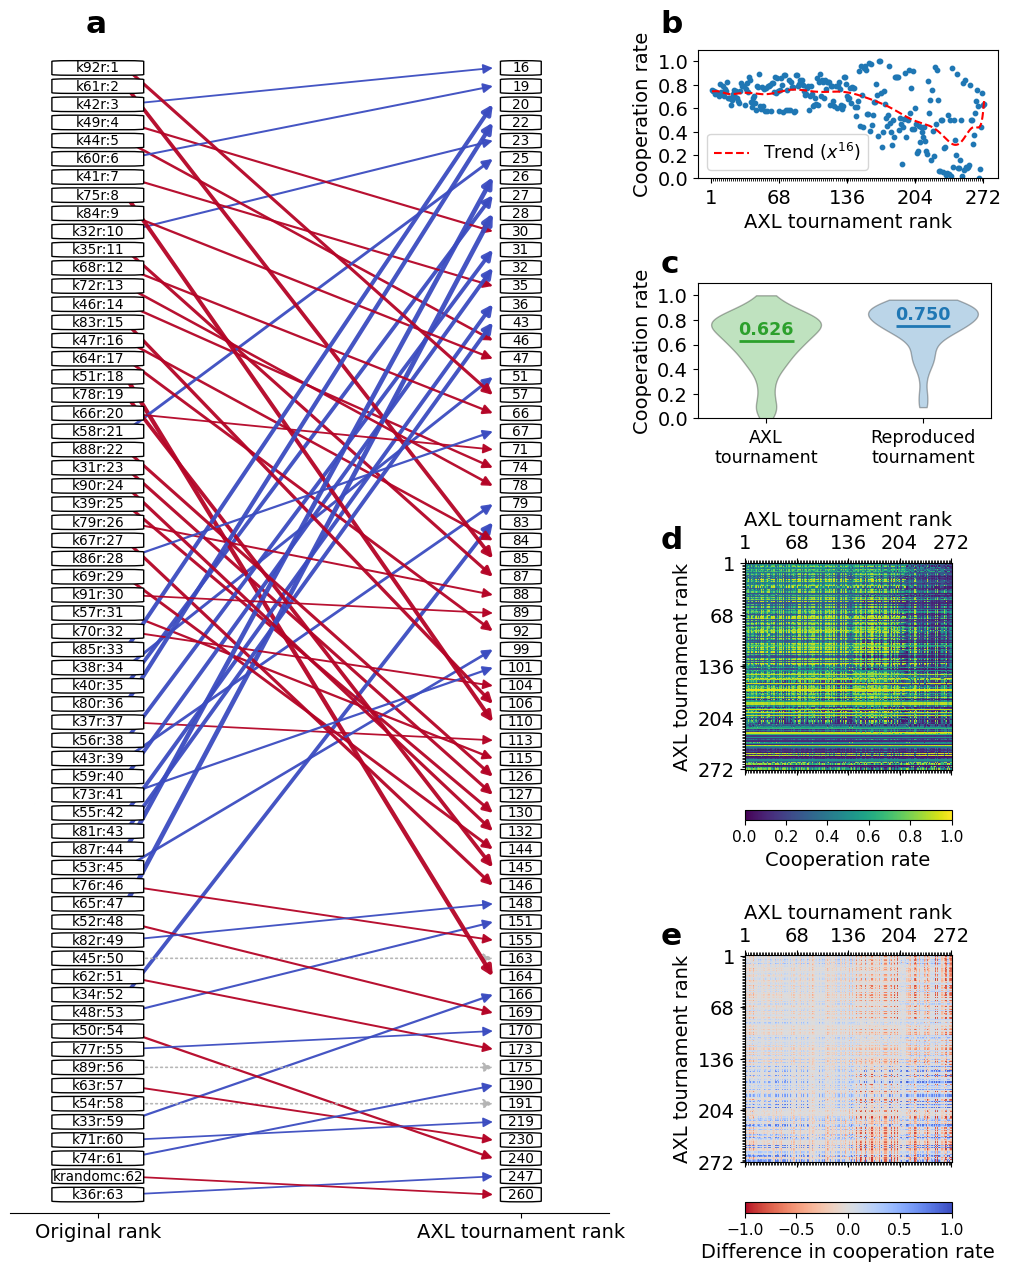

In [117]:
fig, axes = plot_panels(
    ranking_df=full_ranking_df,
    cooperation_df=cooperation_rates,
    label='AXL tournament rank',
    col_x_panel_B="Rank",
    old_rank=original_rank,
    new_rank=full_tournament_rank,
    relative_new_rank=relative_full_tournament_rank,
    save_path='../paper/Figure_7.pdf'
)

### Stewart and Plotkin

In [118]:
stewart_and_plotkin_players = [axl.Cooperator(),
                               axl.Defector(),
                               axl.ZDExtort2(),
                               axl.HardGoByMajority(),
                               axl.FirstByJoss(),
                               axl.HardTitForTat(),
                               axl.HardTitFor2Tats(),
                               axl.TitForTat(),
                               axl.Grudger(),
                               axl.GTFT(),
                               axl.TitFor2Tats(),
                               axl.WinStayLoseShift(),
                               axl.Random(),
                               axl.ZDGTFT2()]
stewart_and_plotkin_player_names = [p.__repr__() for p in stewart_and_plotkin_players]

In [119]:
full_tournament_player_index = pd.read_csv(
    f"{full_tournament_data_path}/players.index",
    names=("Name",),
)

fortran_player_index = pd.read_csv(
    f"{original_tournament_data_path}/players.index",
    names=("Name",),
)
full_tournament_payoff_matrix, repetitions = read_payoff_matrix(
    full_tournament_data_path.glob("*payoff_matrix.gz")
)

In [120]:
implemented_strategies = {characteristics[name]['axelrod-python_class'] : name for name in fortran_player_index["Name"]}

player_names = sorted(list(fortran_player_index["Name"]) + [name for name in stewart_and_plotkin_player_names if name not in implemented_strategies])

In [121]:
sp_scores_df = get_results_of_sub_tournament(
    player_names=player_names, 
    payoff_matrix=full_tournament_payoff_matrix, 
    player_index=full_tournament_player_index["Name"], 
    characteristics=characteristics,
).rename(columns={"Mean payoff": "Mean Score"}).set_index("Name")

sp_cooperation_df = get_results_of_sub_tournament(
    player_names=player_names, 
    payoff_matrix=full_tournament_cooperation_rate_matrix, 
    player_index=full_tournament_player_index["Name"], 
    characteristics=characteristics,
).rename(columns={"Mean payoff": "Mean Cooperation Rate", "Median payoff": "Median Cooperation Rate"}).set_index("Name")

sp_scores_df = sp_scores_df.join(reproduced_df[["Mean Cooperation Rate"]])
sp_scores_df = sp_scores_df.rename(columns={"Mean Cooperation Rate": "Reproduced Mean Cooperation Rate"})
sp_scores = sp_scores_df.join(sp_cooperation_df["Mean Cooperation Rate"])
stewart_and_plotkin_player_names_with_implemented_names = [(name if (name not in implemented_strategies) else implemented_strategies[name]) for name in stewart_and_plotkin_player_names]
sp_only_cooperation_df = get_results_of_sub_tournament(
    player_names=stewart_and_plotkin_player_names_with_implemented_names, 
    payoff_matrix=full_tournament_cooperation_rate_matrix, 
    player_index=full_tournament_player_index["Name"], 
    characteristics=characteristics,
)

sp_only_cooperation_df = sp_only_cooperation_df.rename(columns={"Mean payoff": "S. and P. Mean Cooperation Rate", "Median payoff": "Median Cooperation Rate"}).set_index("Name")
sp_scores = sp_scores.join(sp_only_cooperation_df[["S. and P. Mean Cooperation Rate"]])
sp_ranking_df = sp_scores[["Mean Score", "Rank", "Mean Cooperation Rate", "Reproduced Mean Cooperation Rate", "S. and P. Mean Cooperation Rate"]].round(4)
sp_ranking_df["Rank"] = sp_ranking_df["Rank"].astype(pd.Int64Dtype())

In [122]:
sp_rank = dict(zip(reproduced_df.index, [sp_ranking_df['Rank'][i] for i in reproduced_df.index]))

order = sorted(reproduced_df.index, key=lambda s: (sp_rank[s], original_rank[s]))

relative_sp_rank = {s: i + 1 for i, s in enumerate(order)}

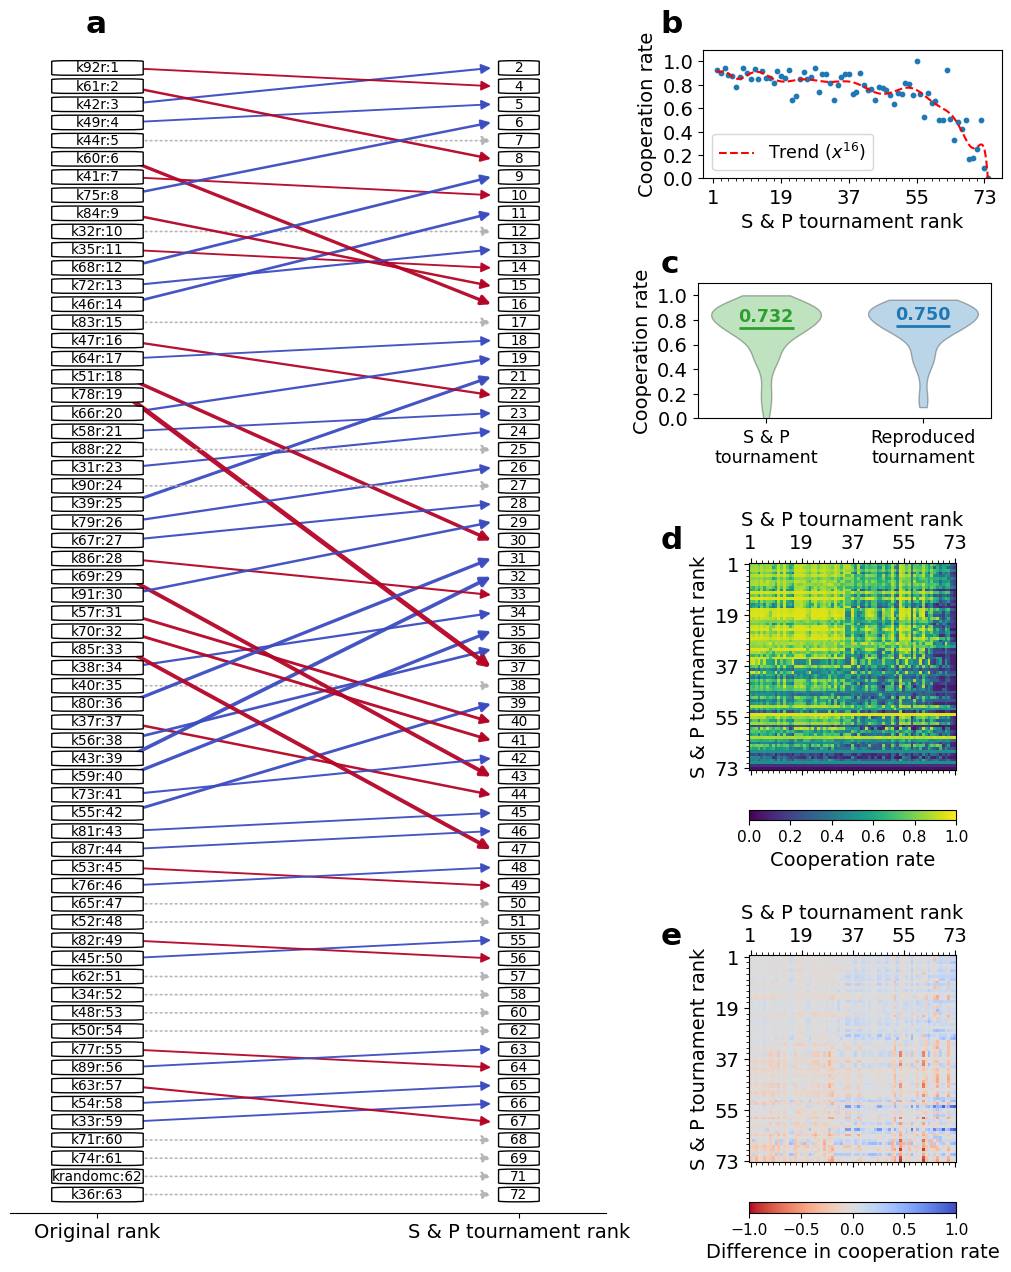

In [123]:
fig, axes = plot_panels(
    ranking_df=sp_ranking_df,
    cooperation_df=sp_only_cooperation_df,
    label=r'S & P tournament rank',
    col_x_panel_B="Rank",
    old_rank=original_rank,
    new_rank=sp_rank,
    relative_new_rank=relative_sp_rank,
    save_path='../paper/Figure_6.pdf'
)

### Noisy tournaments

#### 1% Noise

In [124]:
noisy_tournament_data_path = pathlib.Path("./data/full_tournament_1_percent_noise/")
noisy_tournament_index = pd.read_csv(
    "./data/full_tournament_1_percent_noise/players.index",
    names=("Name",),
)
noisy_tournament_scores = read_tournament_repetitions(
                                   files=full_tournament_data_path.glob("*scores.gz"), 
                                   player_names=full_tournament_index["Name"],
)

In [125]:
noisy_tournament_payoff_matrix, full_repetitions = read_payoff_matrix(noisy_tournament_data_path.glob("*payoff_matrix.gz"))
library_summary_df = pd.read_csv("./data/library_tournament/std_summary.csv")[["Rank", "Name", "Cooperation_rating"]]
library_summary_df = library_summary_df.set_index("Name")
library_summary_df["Rank"] += 1
library_summary_df = library_summary_df.rename(columns={"Rank": "Library Rank", "Cooperation_rating": "Library Mean Cooperation Rate"})

In [126]:
noisy_tournament_cooperation_rate_matrix = read_payoff_matrix(noisy_tournament_data_path.glob("*cooperation_rates.gz"))[0].transpose()
noisy_scores = pd.DataFrame(noisy_tournament_payoff_matrix, 
                           noisy_tournament_index["Name"],
                           columns=noisy_tournament_index["Name"])

noisy_scores["Mean Score"] = np.mean(noisy_tournament_payoff_matrix, axis=1)
noisy_scores["Rank"] = noisy_scores["Mean Score"].rank(ascending=False).astype(int)

cooperation_rates = pd.DataFrame(noisy_tournament_cooperation_rate_matrix, 
                                 noisy_tournament_index["Name"], 
                                 columns=full_tournament_index["Name"])
cooperation_rates["Mean Cooperation Rate"] =  np.mean(noisy_tournament_cooperation_rate_matrix, axis=1)


noisy_scores = noisy_scores.join(cooperation_rates[["Mean Cooperation Rate"]]).sort_values("Rank")

noisy_ranking_df = noisy_scores[["Mean Score", "Rank", "Mean Cooperation Rate"]].round(4)
noisy_ranking_df = pd.merge(noisy_ranking_df, reproduced_df[["Original Rank", "Mean Cooperation Rate"]],
                            left_index=True, right_index=True, how="outer").sort_values("Rank")

noisy_ranking_df = noisy_ranking_df.rename(columns={"Mean Cooperation Rate_x": "Mean Cooperation Rate",
                                                    "Mean Cooperation Rate_y": "Reproduced Mean Cooperation Rate"})


noisy_ranking_df = noisy_ranking_df.join(library_summary_df)

noisy_ranking_df["Original Rank"] = noisy_ranking_df["Original Rank"].astype(pd.Int64Dtype())
noisy_ranking_df["Library Rank"] = noisy_ranking_df["Library Rank"].astype(pd.Int64Dtype())
noisy_ranking_df["Rank"] = noisy_ranking_df["Rank"].astype(pd.Int64Dtype())

In [127]:
noise_one_rank = dict(zip(reproduced_df.index, [noisy_ranking_df['Rank'][i] for i in reproduced_df.index]))

order = sorted(reproduced_df.index, key=lambda s: (noise_one_rank[s], original_rank[s]))

relative_noise_one_rank = {s: i + 1 for i, s in enumerate(order)}

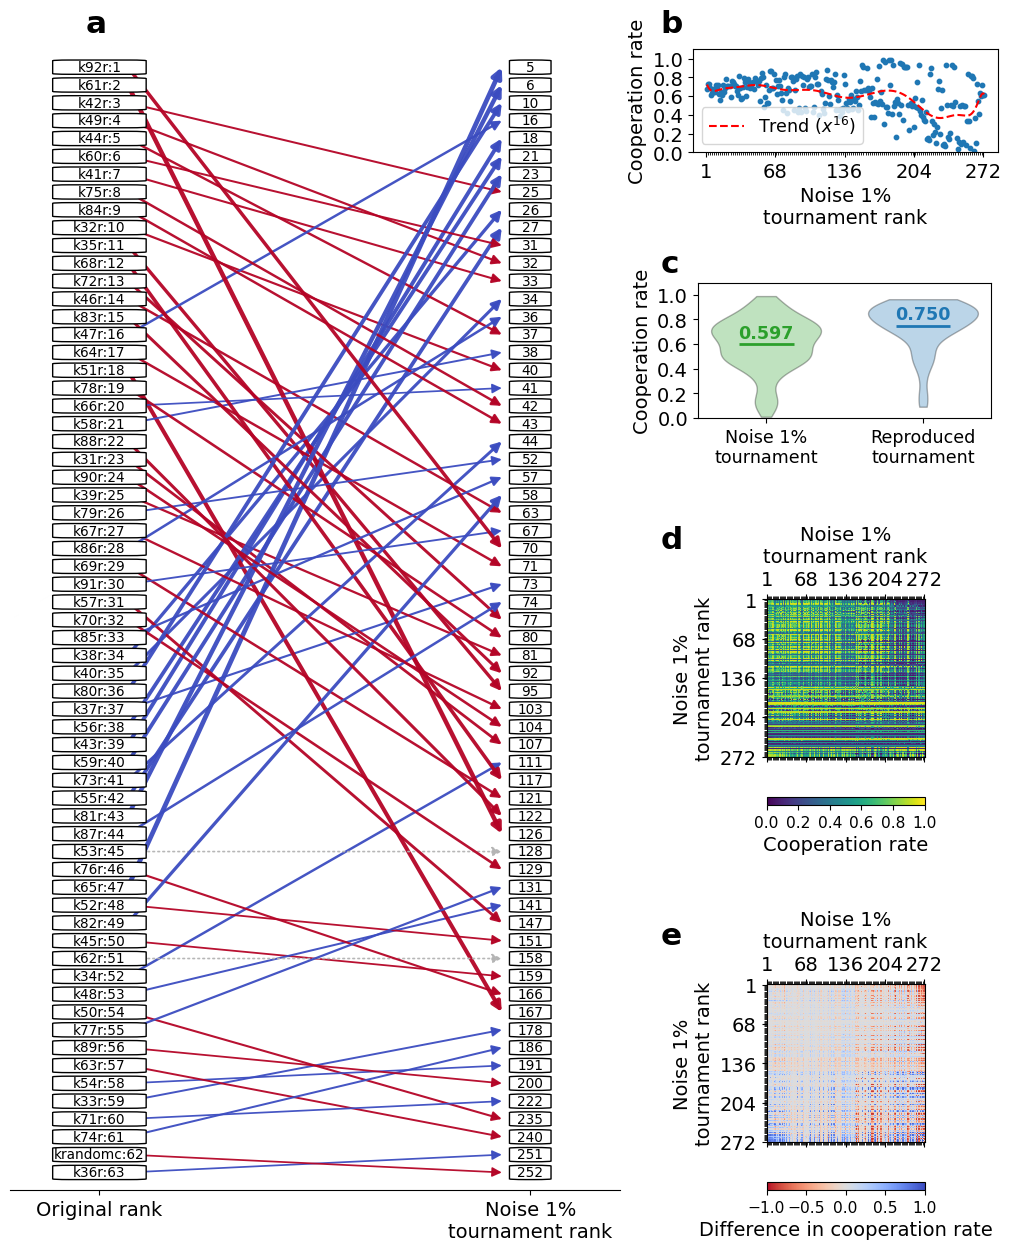

In [141]:
fig, axes = plot_panels(
    ranking_df=noisy_ranking_df,
    cooperation_df=cooperation_rates,
    label='Noise 1%\ntournament rank',
    col_x_panel_B="Rank",
    old_rank=original_rank,
    new_rank=noise_one_rank,
    relative_new_rank=relative_noise_one_rank,
    save_path='../paper/assets/axelrod_python_tournament_noise_1.pdf'
)

#### 5% Noise

In [130]:
noisy5_tournament_data_path = pathlib.Path("./data/full_tournament_5_percent_noise/")
noisy5_tournament_index = pd.read_csv(
    "./data/full_tournament_5_percent_noise/players.index",
    names=("Name",),
)
noisy5_tournament_scores = read_tournament_repetitions(
                                   files=noisy5_tournament_data_path.glob("*scores.gz"), 
                                   player_names=noisy5_tournament_index["Name"],
)

In [131]:
noisy5_tournament_payoff_matrix, full_repetitions = read_payoff_matrix(noisy5_tournament_data_path.glob("*payoff_matrix.gz"))
library_summary_df = pd.read_csv("./data/library_tournament/std_summary.csv")[["Rank", "Name", "Cooperation_rating"]]
library_summary_df = library_summary_df.set_index("Name")
library_summary_df["Rank"] += 1
library_summary_df = library_summary_df.rename(columns={"Rank": "Library Rank", "Cooperation_rating": "Library Mean Cooperation Rate"})

In [132]:
noisy5_tournament_cooperation_rate_matrix = read_payoff_matrix(noisy5_tournament_data_path.glob("*cooperation_rates.gz"))[0].transpose()
noisy5_scores = pd.DataFrame(noisy5_tournament_payoff_matrix, 
                           noisy5_tournament_index["Name"],
                           columns=noisy5_tournament_index["Name"])
noisy5_scores["Mean Score"] = np.mean(noisy5_tournament_payoff_matrix, axis=1)
noisy5_scores["Rank"] = noisy5_scores["Mean Score"].rank(ascending=False).astype(int)

cooperation_rates = pd.DataFrame(noisy5_tournament_cooperation_rate_matrix, 
                                 noisy5_tournament_index["Name"], 
                                 columns=full_tournament_index["Name"])
cooperation_rates["Mean Cooperation Rate"] =  np.mean(noisy5_tournament_cooperation_rate_matrix, axis=1)


noisy5_scores = noisy5_scores.join(cooperation_rates[["Mean Cooperation Rate"]]).sort_values("Rank")

noisy5_ranking_df = noisy5_scores[["Mean Score", "Rank", "Mean Cooperation Rate"]].round(4)
noisy5_ranking_df = pd.merge(noisy5_ranking_df, reproduced_df[["Original Rank", "Mean Cooperation Rate"]],
                            left_index=True, right_index=True, how="outer").sort_values("Rank")

noisy5_ranking_df = noisy5_ranking_df.rename(columns={"Mean Cooperation Rate_x": "Mean Cooperation Rate",
                                                    "Mean Cooperation Rate_y": "Reproduced Mean Cooperation Rate"})


noisy5_ranking_df = noisy5_ranking_df.join(library_summary_df)

noisy5_ranking_df["Original Rank"] = noisy5_ranking_df["Original Rank"].astype(pd.Int64Dtype())
noisy5_ranking_df["Library Rank"] = noisy5_ranking_df["Library Rank"].astype(pd.Int64Dtype())
noisy5_ranking_df["Rank"] = noisy5_ranking_df["Rank"].astype(pd.Int64Dtype())

In [133]:
noise_five_rank = dict(zip(reproduced_df.index, [noisy5_ranking_df['Rank'][i] for i in reproduced_df.index]))

order = sorted(reproduced_df.index, key=lambda s: (noise_five_rank[s], original_rank[s]))

relative_noise_five_rank = {s: i + 1 for i, s in enumerate(order)}

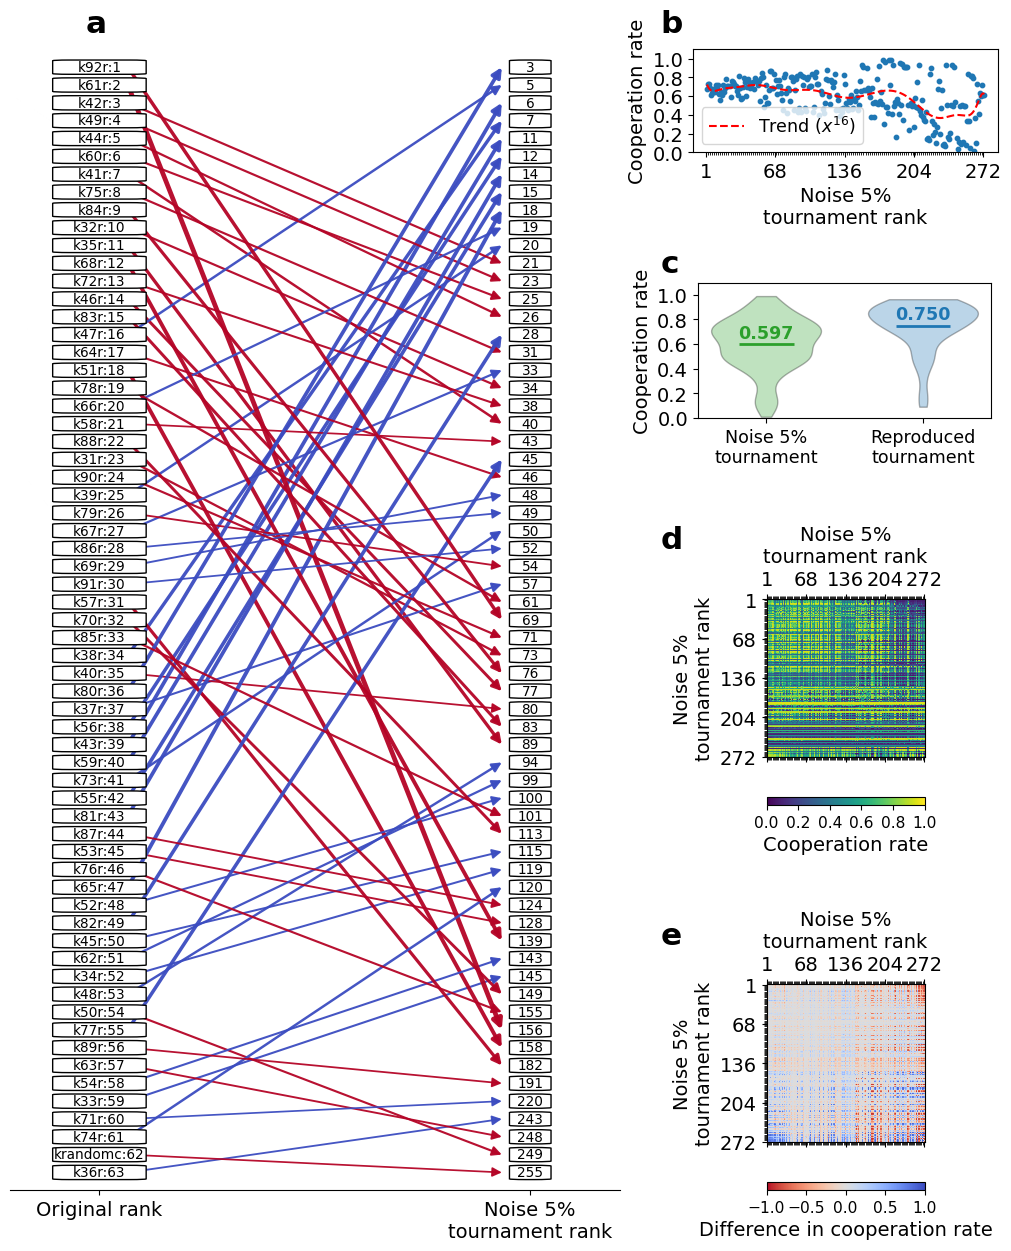

In [140]:
fig, axes = plot_panels(
    ranking_df=noisy_ranking_df,
    cooperation_df=cooperation_rates,
    label='Noise 5%\ntournament rank',
    col_x_panel_B="Rank",
    old_rank=original_rank,
    new_rank=noise_five_rank,
    relative_new_rank=relative_noise_five_rank,
    save_path='../paper/assets/axelrod_python_tournament_noise_5.pdf'
)

In [135]:
original_with_noise = noisy_ranking_df[noisy_ranking_df.index.isin(reproduced_df.index)]

In [136]:
original_with_noise = original_with_noise.sort_values('Mean Score', ascending=False)

original_with_noise['Rank'] = np.arange(1, len(original_with_noise) + 1)

In [137]:
original_with_noise_rank = dict(zip(reproduced_df.index, [original_with_noise['Rank'][i] for i in reproduced_df.index]))

order = sorted(reproduced_df.index, key=lambda s: (original_with_noise_rank[s], original_rank[s]))

relative_original_with_noise_rank = {s: i + 1 for i, s in enumerate(order)}

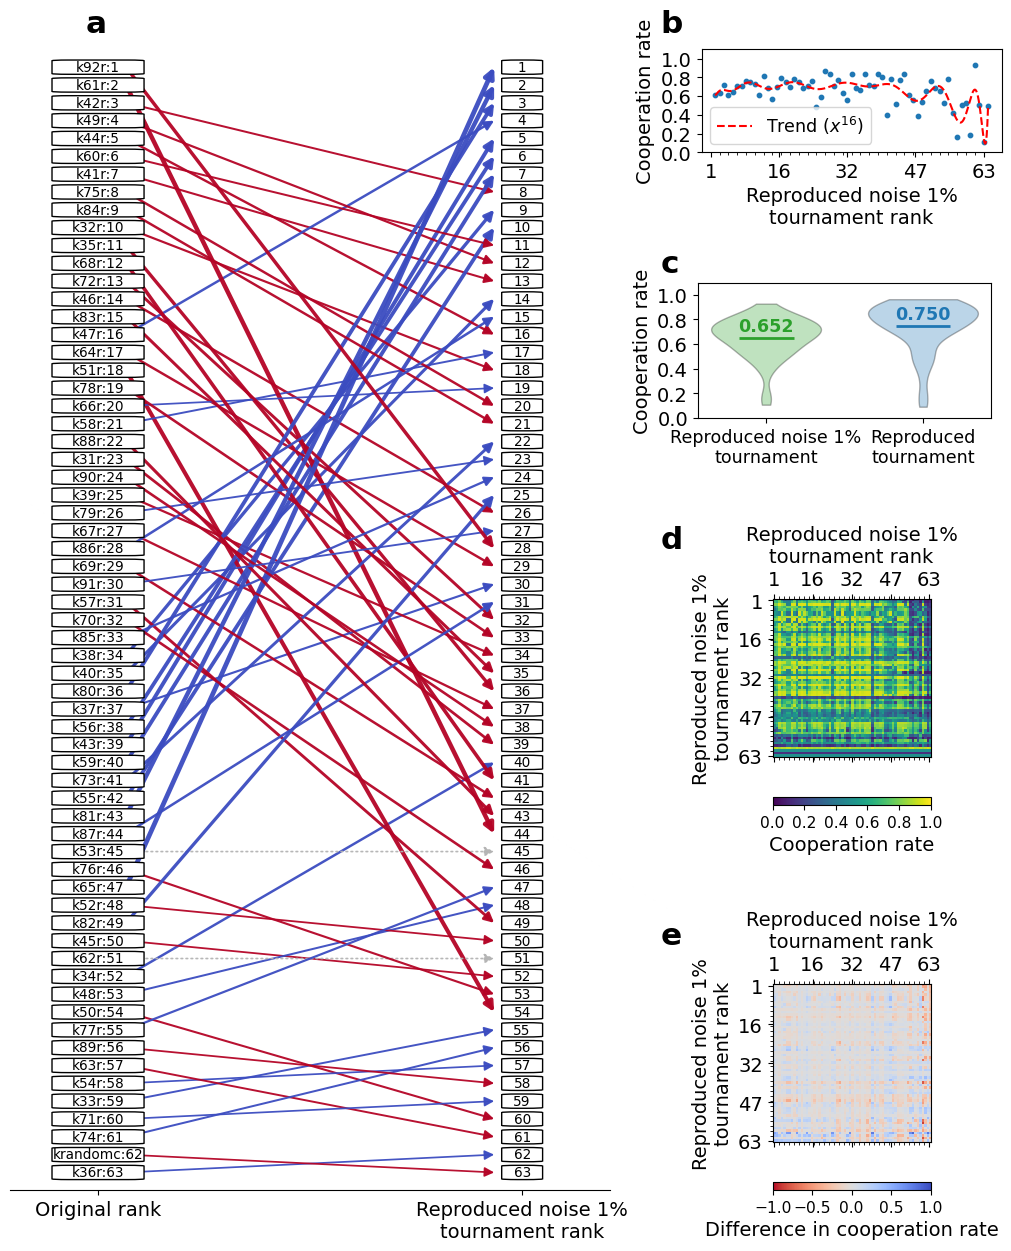

In [138]:
fig, axes = plot_panels(
    ranking_df=original_with_noise,
    cooperation_df=cooperation_rates,
    label='Reproduced noise 1%\ntournament rank',
    col_x_panel_B="Rank",
    old_rank=original_rank,
    new_rank=original_with_noise_rank,
    relative_new_rank=original_with_noise_rank,
    save_path='../paper/Figure_5.pdf'
)

In [39]:
def break_header(s):
    # put your own breaking rule here; example: split on " / " or manual \n
    s = s.replace(" / ", r"\\")
    return r"\makecell[c]{" + s.replace("\n", r"\\") + "}"

In [40]:
table_to_write = reproduced_df[['Original Rank', 'Reproduced Rank']]

In [41]:
table_to_write = table_to_write.join(original_with_noise['Rank'].rename('Reproduced Rank / (Noise 1%)'))

In [42]:
table_to_write = table_to_write.join(sp_ranking_df['Rank'].rename(r'S \& P / tournament Rank'))

In [43]:
table_to_write = table_to_write.join(full_ranking_df['Rank'].rename('AXL / tournament Rank'))

In [44]:
table_to_write = table_to_write.join(noisy_ranking_df['Rank'].rename('AXL (Noise 1%) / tournament Rank'))

In [45]:
table_to_write = table_to_write.join(noisy5_ranking_df['Rank'].rename('AXL (Noise 5%) / tournament Rank'))

In [46]:
table_to_write = table_to_write.rename(columns={"Original Rank": "Original / Rank", "Reproduced Rank": "Reproduced / Rank"})

In [47]:
table_to_write

with open("../paper/assets/original_strategies_rankings.tex", "w") as f:
    f.write(table_to_write.rename(columns=break_header).to_latex(float_format="%.3f", escape=False).replace("%", r"\%").replace("rrrrrrr",
                                                                                                                                "ccccccc"))

In [48]:
sp_top_ten = sp_ranking_df.head(15).fillna("-")

In [49]:
sp_top_ten = sp_top_ten.rename(columns={"Mean Score": "Average / Score", "Mean Cooperation Rate": "Average / Cooperation Rate",
                           "Reproduced Mean Cooperation Rate": "Reproduced Average / Cooperation Rate",
                          "S. and P. Mean Cooperation Rate": "S. and P. Average / Cooperation Rate"})

In [50]:
with open("../paper/assets/sp_tournament_rankings_top_fifteen.tex", "w") as f:
    f.write(sp_top_ten.rename(columns=break_header).to_latex(float_format="%.3f").replace("rrrll", "ccccc"))

In [51]:
sp_full_table = sp_ranking_df.fillna("-")
sp_full_table.index.name = None

In [52]:
sp_full_table = sp_full_table.rename(columns={"Mean Cooperation Rate": "Mean / Cooperation Rate",
                              "Reproduced Rank": "Reproduced / Rank",
                              "Reproduced Mean Cooperation Rate": "Reproduced Mean / Cooperation Rate",
                              "S. and P. Mean Cooperation Rate": "S. and P. Mean / Cooperation Rate"})

In [53]:
with open("../paper/assets/sp_tournament_full_rankings.tex", "w") as f:
    f.write(sp_full_table.rename(columns=break_header).to_latex(float_format="%.3f", escape=False).replace("rrrll", "ccccc"))

In [54]:
sp_top_ten.to_latex()

'\\begin{tabular}{lrrrll}\n\\toprule\n & Average / Score & Rank & Average / Cooperation Rate & Reproduced Average / Cooperation Rate & S. and P. Average / Cooperation Rate \\\\\nName &  &  &  &  &  \\\\\n\\midrule\nZD-GTFT-2: 0.25, 0.5 & 2.834200 & 1 & 0.926400 & - & 0.855100 \\\\\nk42r & 2.825000 & 2 & 0.903500 & 0.916100 & - \\\\\nGTFT: 0.33 & 2.818800 & 3 & 0.941300 & - & 0.893100 \\\\\nk92r & 2.811900 & 4 & 0.887600 & 0.921800 & 0.730500 \\\\\nk49r & 2.786600 & 5 & 0.878600 & 0.892200 & - \\\\\nk75r & 2.786200 & 6 & 0.782500 & 0.801900 & - \\\\\nk44r & 2.781100 & 7 & 0.866100 & 0.881900 & - \\\\\nk61r & 2.772700 & 8 & 0.944600 & 0.954200 & - \\\\\nk68r & 2.768300 & 9 & 0.904400 & 0.916900 & - \\\\\nk41r & 2.761500 & 10 & 0.846500 & 0.865000 & - \\\\\nk46r & 2.758100 & 11 & 0.938700 & 0.948300 & - \\\\\nk32r & 2.758100 & 12 & 0.848600 & 0.872600 & - \\\\\nk72r & 2.755500 & 13 & 0.914700 & 0.924200 & - \\\\\nk35r & 2.746500 & 14 & 0.862900 & 0.887800 & - \\\\\nk84r & 2.745400 & 15 & 

In [55]:
table_full = full_ranking_df.head(16)

In [56]:
table_full = table_full.rename(columns={"Mean Score": "Average / Score", "Mean Cooperation Rate": "Average / Cooperation Rate",
                           "Reproduced Mean Cooperation Rate": "Reproduced Average / Cooperation Rate",
                           "Library Mean Cooperation Rate": "Library Average / Cooperation Rate"})

In [57]:
table_full.index = table_full.index.map(add_superscript_to_name)
table_full = table_full.astype(object)
table_full = table_full.fillna("-")

with open("../paper/assets/axelord_python_tournament_rankings_top_sixteen.tex", "w") as f:
    f.write(table_full.rename(columns=break_header).to_latex(float_format="%.3f", escape=False).replace("rrrllll", "ccccccc").replace("_", "\_"))

<>:6: SyntaxWarning: invalid escape sequence '\_'
<>:6: SyntaxWarning: invalid escape sequence '\_'
/var/folders/95/bfy4zf7n6p5248zz4wn2txfm0000gn/T/ipykernel_96901/2230620920.py:6: SyntaxWarning: invalid escape sequence '\_'
  f.write(table_full.rename(columns=break_header).to_latex(float_format="%.3f", escape=False).replace("rrrllll", "ccccccc").replace("_", "\_"))
/var/folders/95/bfy4zf7n6p5248zz4wn2txfm0000gn/T/ipykernel_96901/2230620920.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table_full = table_full.fillna("-")


In [58]:
table_full = full_ranking_df

In [59]:
table_full = table_full.rename(columns={"Mean Score": "Average / Score", "Mean Cooperation Rate": "Average / Cooperation Rate",
                           "Reproduced Mean Cooperation Rate": "Reproduced Average / Cooperation Rate",
                           "Library Mean Cooperation Rate": "Library Average / Cooperation Rate"})

In [60]:
table_full.index = table_full.index.map(add_superscript_to_name)
table_full = table_full.astype(object)
table_full = table_full.fillna("-")

with open("../paper/assets/axelord_python_tournament_rankings_full.tex", "w") as f:
    f.write(table_full.rename(columns=break_header).to_latex(float_format="%.3f", escape=False).replace("rrrllll", "ccccccc").replace("_", "\_"))

<>:6: SyntaxWarning: invalid escape sequence '\_'
<>:6: SyntaxWarning: invalid escape sequence '\_'
/var/folders/95/bfy4zf7n6p5248zz4wn2txfm0000gn/T/ipykernel_96901/2197134123.py:6: SyntaxWarning: invalid escape sequence '\_'
  f.write(table_full.rename(columns=break_header).to_latex(float_format="%.3f", escape=False).replace("rrrllll", "ccccccc").replace("_", "\_"))
/var/folders/95/bfy4zf7n6p5248zz4wn2txfm0000gn/T/ipykernel_96901/2197134123.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table_full = table_full.fillna("-")


## SI page with list of all strategies

In [61]:
dfs = [full_ranking_df[["Rank", "Original Rank"]], noisy_ranking_df[["Rank"]].rename(columns={"Rank": "Rank with 1% Noise"}), noisy5_ranking_df[["Rank"]].rename(columns={"Rank": "Rank with 5% Noise"})]

In [62]:
merged_df = dfs[0].merge(dfs[1], left_index=True, right_index=True).merge(dfs[2], left_index=True, right_index=True)
merged_df.head(30)

,Rank,Original Rank,Rank with 1% Noise,Rank with 5% Noise
EvolvedLookerUp2_2_2,1,<NA>,30,118
Evolved HMM 5,2,<NA>,13,59
"Omega TFT: 3, 8",3,<NA>,4,17
Evolved ANN 5,4,<NA>,7,36
Evolved ANN,5,<NA>,3,8
Evolved FSM 16,6,<NA>,15,78
Evolved FSM 16 Noise 05,7,<NA>,1,4
PSO Gambler 2_2_2,8,<NA>,53,138
Original Gradual,9,<NA>,20,30
PSO Gambler 2_2_2 Noise 05,10,<NA>,9,24


In [63]:
with open("../paper/assets/list_of_all_players.tex", "w") as f:
    for name, row in merged_df.iterrows():
        name = name.replace("_", "\_")
        if str(row["Original Rank"]) == "<NA>":
            f.write(f"\\item {name}: {row["Rank"]} / {row["Rank with 1% Noise"]} / {row["Rank with 5% Noise"]}\n")
        else:
            f.write(f"\\item {name}: {row["Rank"]} / {row["Rank with 1% Noise"]} / {row["Rank with 5% Noise"]} / {row["Original Rank"]}\n")


<>:3: SyntaxWarning: invalid escape sequence '\_'
<>:3: SyntaxWarning: invalid escape sequence '\_'
/var/folders/95/bfy4zf7n6p5248zz4wn2txfm0000gn/T/ipykernel_96901/1374620979.py:3: SyntaxWarning: invalid escape sequence '\_'
  name = name.replace("_", "\_")
